# CageMind — Análisis Exploratorio de Datos (EDA)
**Proyecto:** Predictor de peleas UFC con Machine Learning  
**Dataset:** UFCStats.com + Sherdog (vía scraping propio)  
**Objetivo:** Entender la distribución del dataset, identificar patrones predictivos y detectar anomalías antes del feature engineering.

---
### Estructura del notebook
1. Carga de datos desde SQLite
2. Resumen general del dataset
3. Análisis de peleadores (peso, stance, altura, reach, win rate)
4. Análisis de peleas (métodos de victoria, rounds, tendencia temporal)
5. Fight stats (golpes por zona, takedowns, control time)
6. Patrones predictivos (ganadores vs perdedores, ventaja de reach, correlaciones)
7. Anomalías y valores atípicos


## 0. Imports y configuración

In [1]:
from __future__ import annotations
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()

sys.path.append(os.path.abspath(".."))
from backend.config import DATABASE_URL

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

CHARTS_DIR = Path("data/exports/charts")
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga de datos

Cargamos las 5 tablas principales desde la base de datos SQLite generada en la Fase 1 (scraping de UFCStats + Sherdog).

| Tabla | Descripción |
|---|---|
| `fighters` | Perfil físico y carrera de cada peleador |
| `events` | Metadata de cada evento UFC |
| `fights` | Resultado de cada pelea |
| `fight_stats` | Estadísticas por round y por peleador |
| `data_quality` | Nivel de completitud de cada registro |


In [2]:
import os
import pandas as pd
import psycopg2
from dotenv import load_dotenv

load_dotenv(override=True)

DATABASE_URL = os.getenv("DATABASE_URL_NB")

conn = psycopg2.connect(DATABASE_URL)

fighters     = pd.read_sql_query("SELECT * FROM fighters", conn)
events       = pd.read_sql_query("SELECT * FROM events", conn)
fights       = pd.read_sql_query("SELECT * FROM fights", conn)
fight_stats  = pd.read_sql_query("SELECT * FROM fight_stats", conn)
data_quality = pd.read_sql_query("SELECT * FROM data_quality", conn)

conn.close()

print(f"Peleadores:   {len(fighters):,}")
print(f"Eventos:      {len(events):,}")
print(f"Peleas:       {len(fights):,}")
print(f"Fight stats:  {len(fight_stats):,} filas (2 por pelea)")

C:\Users\PC PRIDE WHITE WOLF\AppData\Local\Temp\ipykernel_38136\851212178.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fighters     = pd.read_sql_query("SELECT * FROM fighters", conn)
C:\Users\PC PRIDE WHITE WOLF\AppData\Local\Temp\ipykernel_38136\851212178.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  events       = pd.read_sql_query("SELECT * FROM events", conn)
C:\Users\PC PRIDE WHITE WOLF\AppData\Local\Temp\ipykernel_38136\851212178.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fights       = pd.re

Peleadores:   4,455
Eventos:      769
Peleas:       8,636
Fight stats:  17,230 filas (2 por pelea)


C:\Users\PC PRIDE WHITE WOLF\AppData\Local\Temp\ipykernel_38136\851212178.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_quality = pd.read_sql_query("SELECT * FROM data_quality", conn)


## 2. Resumen general y calidad de datos

Antes de modelar es crítico entender qué tan completo está el dataset.  
Un **Cold Start Problem** aparece con peleadores debutantes que no tienen historial — uno de los retos centrales que CageMind resuelve con datos de Sherdog.


In [3]:
# Calidad de datos por nivel de detalle
quality_counts = data_quality["detail_level"].value_counts()
print("Calidad de datos:")
for level, count in quality_counts.items():
    pct = count / len(data_quality) * 100
    print(f"  {level}: {count:,} ({pct:.1f}%)")

# Datos faltantes en fighters
print("\nDatos faltantes en fighters:")
missing_cols = ["height_inches", "reach_inches", "weight_lbs", "stance", "dob"]
missing_df = pd.DataFrame({
    "columna": missing_cols,
    "nulos": [fighters[c].isna().sum() for c in missing_cols],
    "pct": [fighters[c].isna().mean()*100 for c in missing_cols]
})
display(missing_df.style.format({"pct": "{:.1f}%", "nulos": "{:,}"}))


Calidad de datos:
  full: 8,614 (99.7%)
  result_only: 22 (0.3%)

Datos faltantes en fighters:


,columna,nulos,pct
0,height_inches,318,7.1%
1,reach_inches,"1,940",43.5%
2,weight_lbs,86,1.9%
3,stance,849,19.1%
4,dob,504,11.3%


## 3. Análisis de peleadores

Exploramos la distribución física de los peleadores. Esto es relevante para el modelo porque atributos como **reach** y **peso** son features con alta correlación con el resultado.


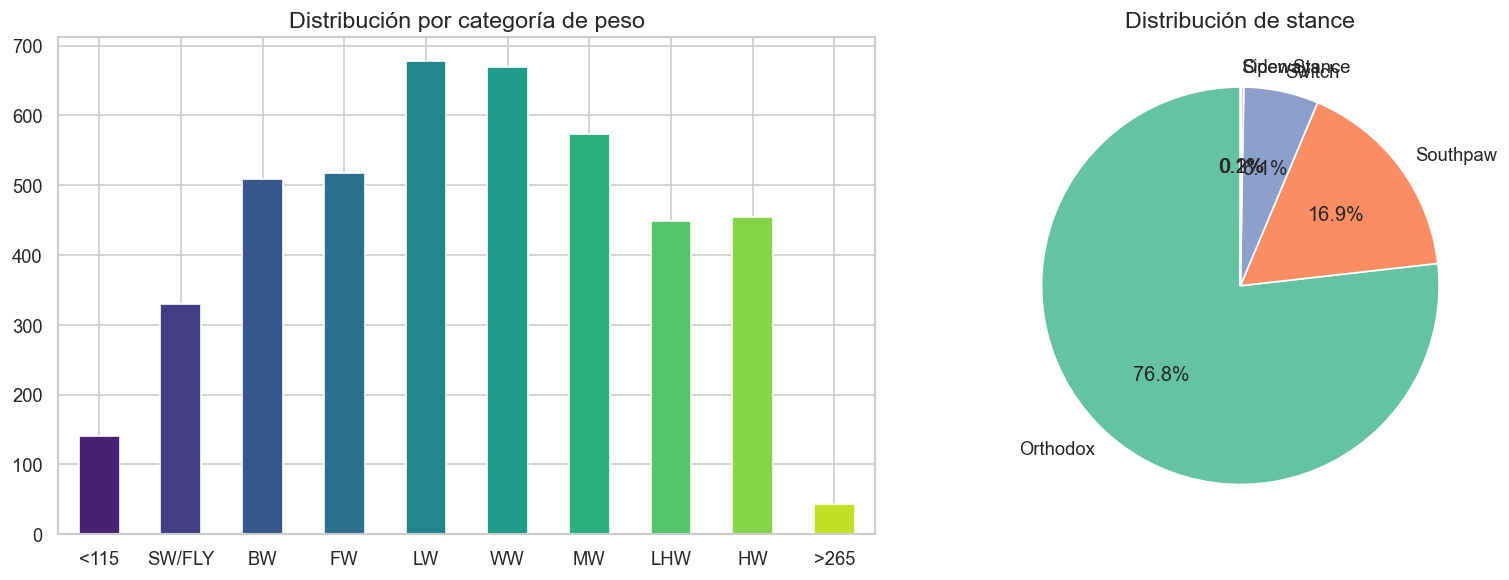

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución por categoría de peso
weight_bins   = [0, 115, 125, 135, 145, 155, 170, 185, 205, 265, 400]
weight_labels = ["<115","SW/FLY","BW","FW","LW","WW","MW","LHW","HW",">265"]
fighters["weight_class_bin"] = pd.cut(fighters["weight_lbs"].dropna(),
                                       bins=weight_bins, labels=weight_labels)
wc = fighters["weight_class_bin"].value_counts().sort_index()
wc.plot(kind="bar", ax=axes[0], color=sns.color_palette("viridis", len(wc)))
axes[0].set_title("Distribución por categoría de peso")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Stance
stance = fighters["stance"].dropna().value_counts()
axes[1].pie(stance.values, labels=stance.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2", len(stance)), startangle=90)
axes[1].set_title("Distribución de stance")

plt.tight_layout()
plt.savefig(CHARTS_DIR / "01_peleadores_peso_stance.png", bbox_inches="tight")
plt.show()


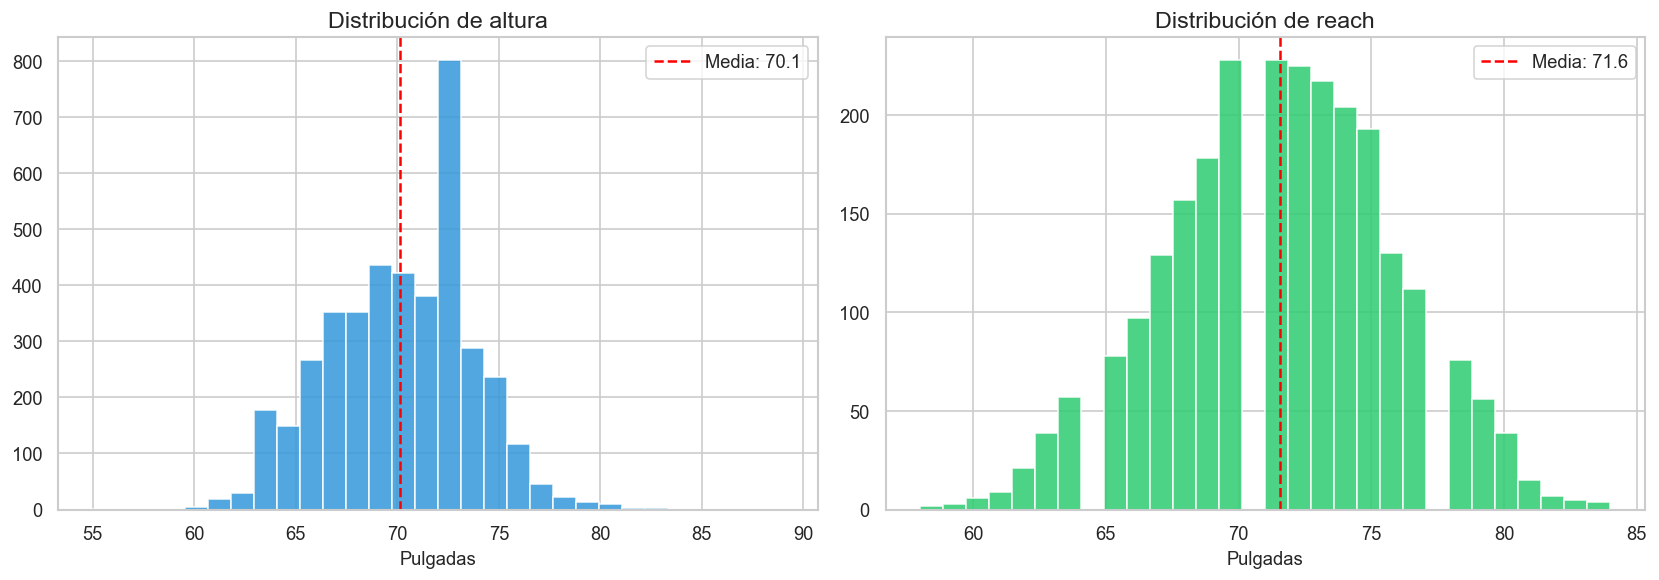

Altura — media: 70.1, std: 3.5
Reach  — media: 71.6, std: 4.3


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

height_data = fighters["height_inches"].dropna()
reach_data  = fighters["reach_inches"].dropna()

axes[0].hist(height_data, bins=30, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(height_data.mean(), color="red", linestyle="--",
                label=f"Media: {height_data.mean():.1f}")
axes[0].set_title("Distribución de altura")
axes[0].set_xlabel("Pulgadas")
axes[0].legend()

axes[1].hist(reach_data, bins=30, color="#2ecc71", edgecolor="white", alpha=0.85)
axes[1].axvline(reach_data.mean(), color="red", linestyle="--",
                label=f"Media: {reach_data.mean():.1f}")
axes[1].set_title("Distribución de reach")
axes[1].set_xlabel("Pulgadas")
axes[1].legend()

plt.tight_layout()
plt.savefig(CHARTS_DIR / "02_altura_reach.png", bbox_inches="tight")
plt.show()

print(f"Altura — media: {height_data.mean():.1f}, std: {height_data.std():.1f}")
print(f"Reach  — media: {reach_data.mean():.1f}, std: {reach_data.std():.1f}")

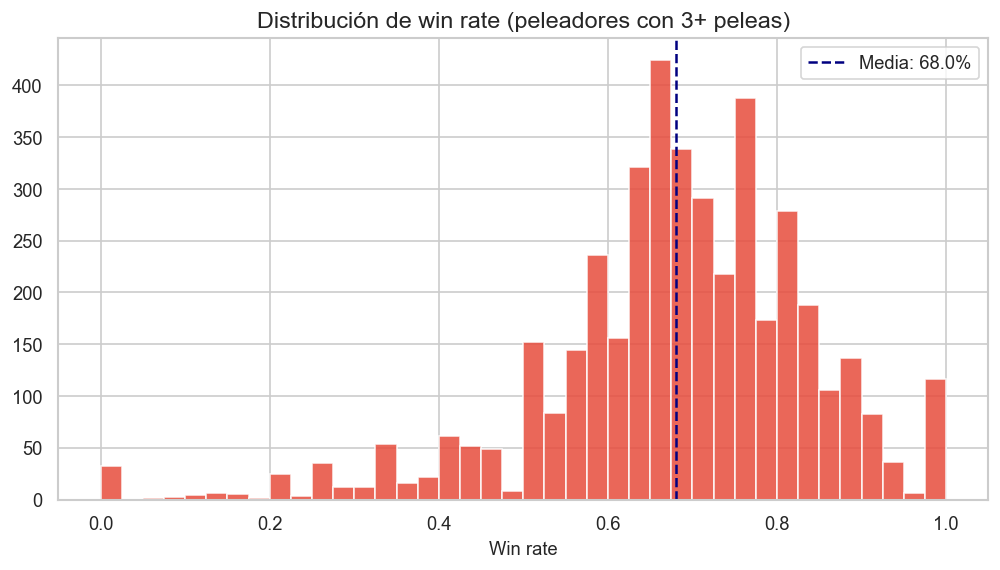

Peleadores con 3+ peleas: 4,278
Win rate promedio: 68.0%


In [6]:
# Win rate de peleadores con al menos 3 peleas
fighters_copy = fighters.copy()
fighters_copy["total_fights"] = fighters_copy["wins"] + fighters_copy["losses"] + fighters_copy["draws"]
fighters_copy["win_rate"] = fighters_copy["wins"] / fighters_copy["total_fights"].replace(0, 1)
active = fighters_copy[fighters_copy["total_fights"] >= 3]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(active["win_rate"], bins=40, color="#e74c3c", edgecolor="white", alpha=0.85)
ax.axvline(active["win_rate"].mean(), color="navy", linestyle="--",
           label=f"Media: {active['win_rate'].mean():.1%}")
ax.set_title("Distribución de win rate (peleadores con 3+ peleas)")
ax.set_xlabel("Win rate")
ax.legend()
plt.savefig(CHARTS_DIR / "03_win_rate.png", bbox_inches="tight")
plt.show()

print(f"Peleadores con 3+ peleas: {len(active):,}")
print(f"Win rate promedio: {active['win_rate'].mean():.1%}")


## 4. Análisis de peleas

Analizamos cómo terminan las peleas. La distribución de métodos de victoria es relevante para diseñar el target variable del modelo — predecir ganador binario vs predecir método de victoria son dos problemas distintos.


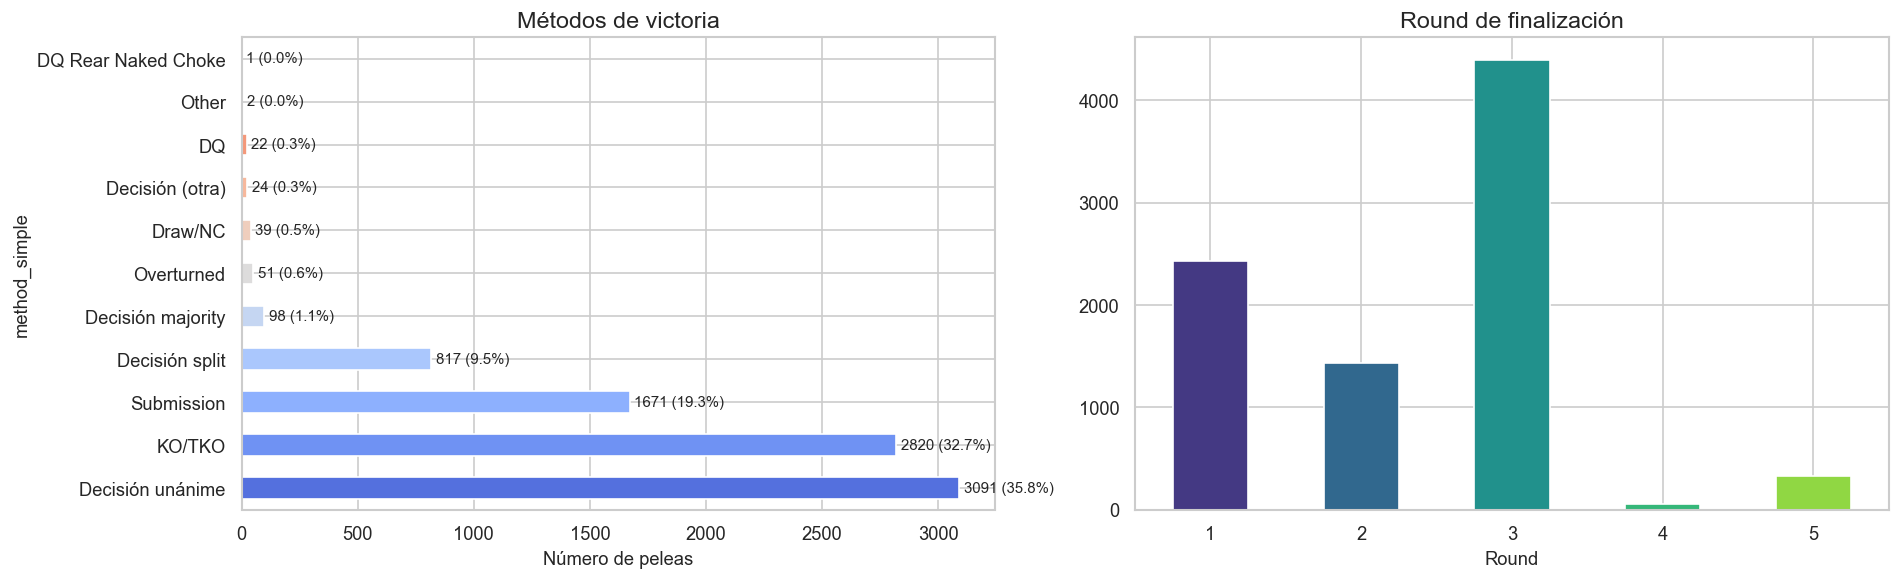

In [7]:
def simplify_method(method):
    if not method:
        return "Desconocido"
    m = method.upper()
    if "KO" in m or "TKO" in m:    return "KO/TKO"
    elif "SUB" in m:                return "Submission"
    elif "U-DEC" in m:              return "Decisión unánime"
    elif "S-DEC" in m:              return "Decisión split"
    elif "M-DEC" in m:              return "Decisión majority"
    elif "DEC" in m:                return "Decisión (otra)"
    elif "DRAW" in m or "NC" in m:  return "Draw/NC"
    elif "OVERTURNED" in m:         return "Overturned"
    return method[:30]

fights_copy = fights.copy()
fights_copy["method_simple"] = fights_copy["method"].apply(
    lambda x: simplify_method(x) if pd.notna(x) else "Desconocido"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

method_counts = fights_copy["method_simple"].value_counts()
method_counts.plot(kind="barh", ax=axes[0], color=sns.color_palette("coolwarm", len(method_counts)))
for i, v in enumerate(method_counts.values):
    axes[0].text(v + 20, i, f"{v} ({v/len(fights)*100:.1f}%)", va="center", fontsize=9)
axes[0].set_title("Métodos de victoria")
axes[0].set_xlabel("Número de peleas")

round_counts = fights_copy["round"].dropna().astype(int).value_counts().sort_index()
round_counts.plot(kind="bar", ax=axes[1], color=sns.color_palette("viridis", len(round_counts)))
axes[1].set_title("Round de finalización")
axes[1].set_xlabel("Round")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "04_metodos_rounds.png", bbox_inches="tight")
plt.show()


## 5. Fight stats — distribución de golpes

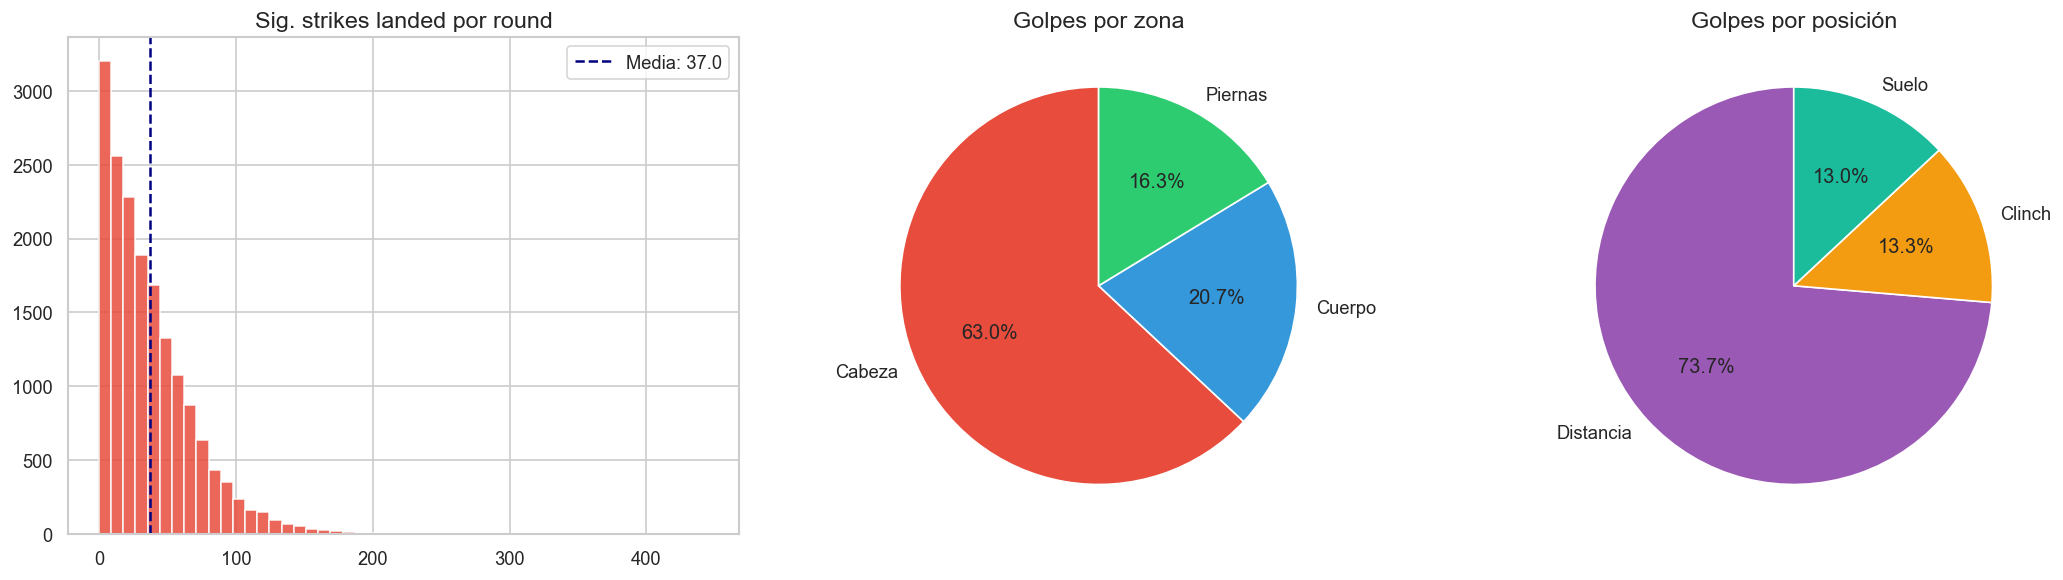

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sig strikes
ss = fight_stats["sig_strikes_landed"].dropna()
axes[0].hist(ss, bins=50, color="#e74c3c", edgecolor="white", alpha=0.85)
axes[0].axvline(ss.mean(), color="navy", linestyle="--", label=f"Media: {ss.mean():.1f}")
axes[0].set_title("Sig. strikes landed por round")
axes[0].legend()

# Distribución por zona
zones = {
    "Cabeza":  fight_stats["head_landed"].dropna().sum(),
    "Cuerpo":  fight_stats["body_landed"].dropna().sum(),
    "Piernas": fight_stats["leg_landed"].dropna().sum(),
}
axes[1].pie(zones.values(), labels=zones.keys(), autopct="%1.1f%%",
            colors=["#e74c3c","#3498db","#2ecc71"], startangle=90)
axes[1].set_title("Golpes por zona")

# Distribución por posición
positions = {
    "Distancia": fight_stats["distance_landed"].dropna().sum(),
    "Clinch":    fight_stats["clinch_landed"].dropna().sum(),
    "Suelo":     fight_stats["ground_landed"].dropna().sum(),
}
axes[2].pie(positions.values(), labels=positions.keys(), autopct="%1.1f%%",
            colors=["#9b59b6","#f39c12","#1abc9c"], startangle=90)
axes[2].set_title("Golpes por posición")

plt.tight_layout()
plt.savefig(CHARTS_DIR / "05_fight_stats.png", bbox_inches="tight")
plt.show()


## 6. Patrones predictivos

Esta sección es el puente entre EDA y feature engineering. Queremos saber **qué variables discriminan ganadores de perdedores** — esas serán candidatas a features del modelo XGBoost.


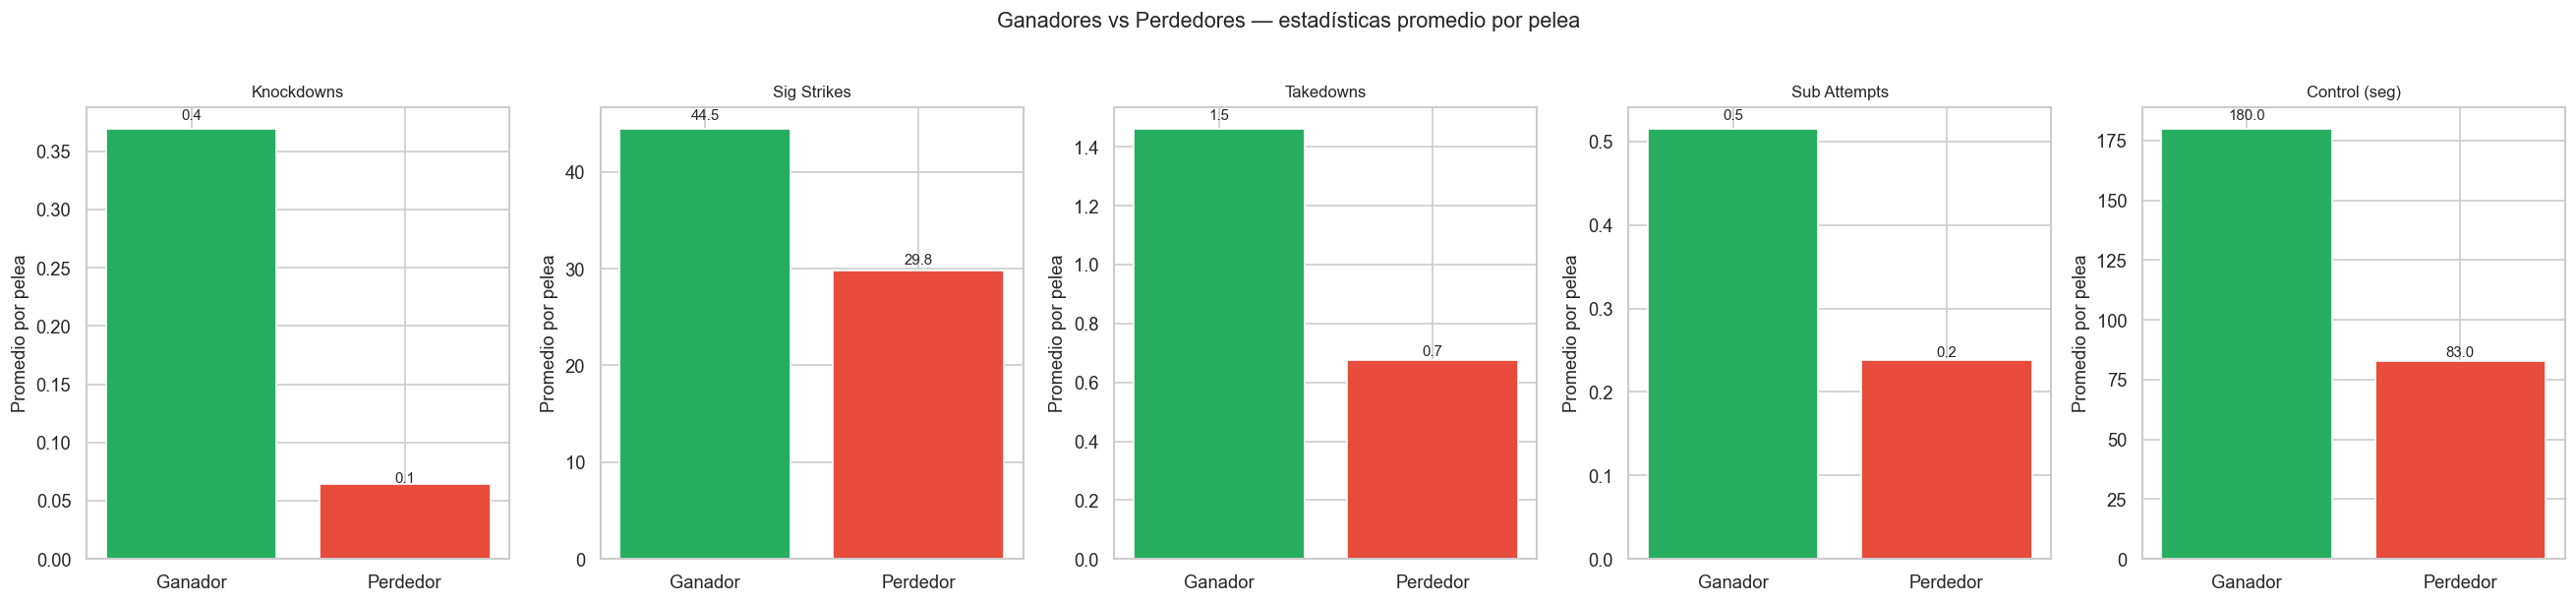

In [9]:
# Agregar stats por pelea (sumar todos los rounds)
agg = fight_stats.groupby(["fight_id","fighter_name"]).agg(
    total_kd       = ("knockdowns", "sum"),
    total_sig      = ("sig_strikes_landed", "sum"),
    total_td       = ("takedowns_landed", "sum"),
    total_sub      = ("submission_attempts", "sum"),
    total_ctrl     = ("control_time_seconds", "sum"),
).reset_index()

merged = agg.merge(
    fights[["fight_id","winner_name","fighter_a_name","fighter_b_name"]],
    on="fight_id", how="inner"
)
merged["is_winner"] = (merged["fighter_name"] == merged["winner_name"]).astype(int)

winners = merged[merged["is_winner"] == 1]
losers  = merged[merged["is_winner"] == 0]

cols   = ["total_kd","total_sig","total_td","total_sub","total_ctrl"]
labels = ["Knockdowns","Sig Strikes","Takedowns","Sub Attempts","Control (seg)"]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, (col, label) in enumerate(zip(cols, labels)):
    w, l = winners[col].mean(), losers[col].mean()
    axes[i].bar(["Ganador","Perdedor"], [w, l], color=["#27ae60","#e74c3c"], edgecolor="white")
    axes[i].set_title(label, fontsize=10)
    axes[i].set_ylabel("Promedio por pelea")
    axes[i].text(0, w*1.02, f"{w:.1f}", ha="center", fontsize=9)
    axes[i].text(1, l*1.02, f"{l:.1f}", ha="center", fontsize=9)

fig.suptitle("Ganadores vs Perdedores — estadísticas promedio por pelea", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "06_ganadores_vs_perdedores.png", bbox_inches="tight")
plt.show()


C:\Users\PC PRIDE WHITE WOLF\AppData\Local\Temp\ipykernel_38136\9835628.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reach_wr = fr.groupby("reach_group")["a_won"].mean()


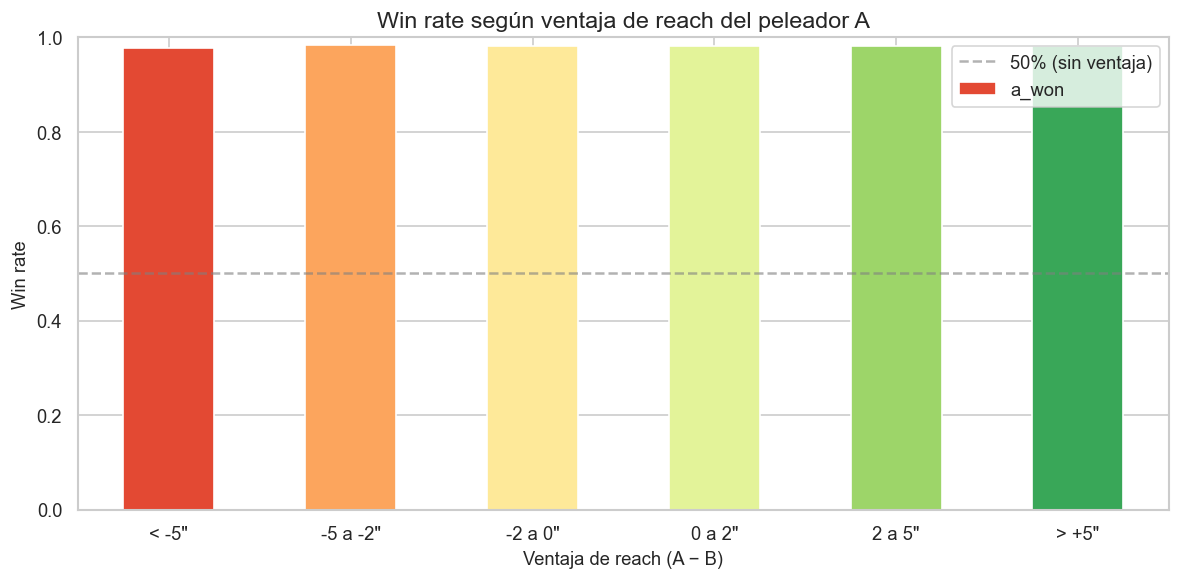

Hallazgo: peleadores con > 5" de ventaja de reach ganan 98.1% de las peleas.


In [10]:
# Ventaja de reach y win rate
fighter_reach = fighters[["name","reach_inches"]].dropna(subset=["reach_inches"])

fr = fights.copy()
fr = fr.merge(fighter_reach.rename(columns={"name":"fighter_a_name","reach_inches":"reach_a"}),
              on="fighter_a_name", how="left")
fr = fr.merge(fighter_reach.rename(columns={"name":"fighter_b_name","reach_inches":"reach_b"}),
              on="fighter_b_name", how="left")
fr = fr.dropna(subset=["reach_a","reach_b"])
fr["reach_diff"] = fr["reach_a"] - fr["reach_b"]
fr["a_won"]      = (fr["winner_name"] == fr["fighter_a_name"]).astype(int)
fr["reach_group"] = pd.cut(fr["reach_diff"],
    bins=[-20,-5,-2,0,2,5,20],
    labels=['< -5"','-5 a -2"','-2 a 0"','0 a 2"','2 a 5"','> +5"'])

reach_wr = fr.groupby("reach_group")["a_won"].mean()

fig, ax = plt.subplots(figsize=(10,5))
reach_wr.plot(kind="bar", ax=ax, color=sns.color_palette("RdYlGn", len(reach_wr)))
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="50% (sin ventaja)")
ax.set_title("Win rate según ventaja de reach del peleador A")
ax.set_xlabel("Ventaja de reach (A − B)")
ax.set_ylabel("Win rate")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS_DIR / "07_reach_vs_winrate.png", bbox_inches="tight")
plt.show()

print(f"Hallazgo: peleadores con > 5\" de ventaja de reach ganan {reach_wr.iloc[-1]:.1%} de las peleas.")

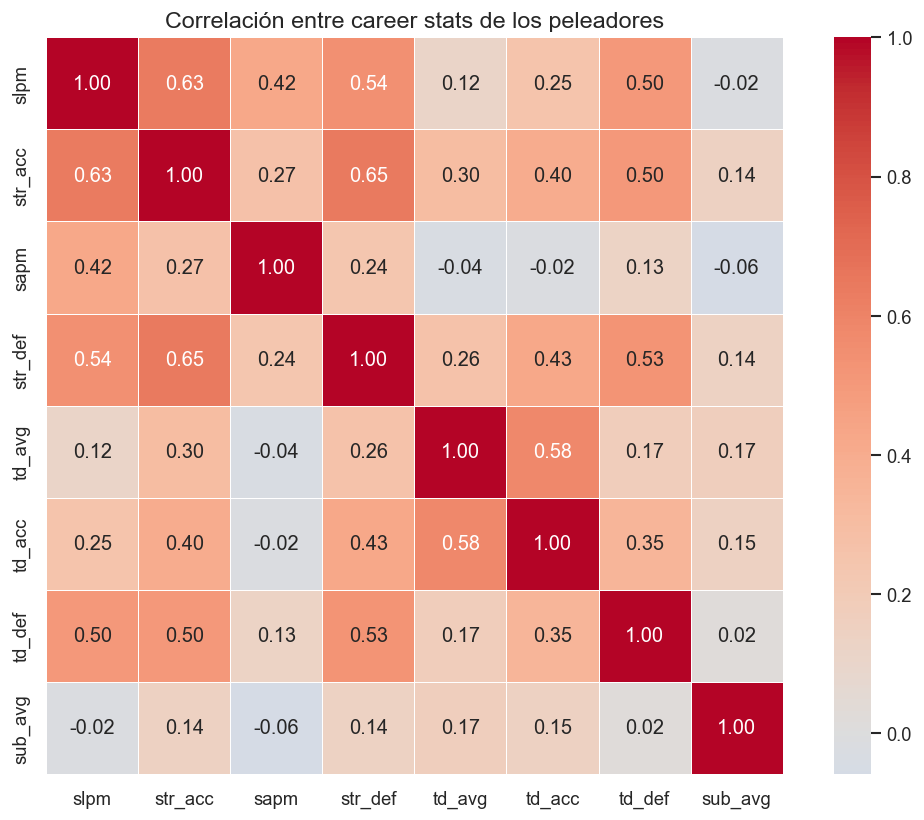

In [11]:
# Matriz de correlación entre career stats
career_cols = ["slpm","str_acc","sapm","str_def","td_avg","td_acc","td_def","sub_avg"]
career_data = fighters[career_cols].dropna()

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(career_data.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlación entre career stats de los peleadores")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "08_correlacion_career_stats.png", bbox_inches="tight")
plt.show()


## 7. Anomalías y valores atípicos

Identificamos registros problemáticos que podrían sesgar el modelo si no se tratan en el pipeline de feature engineering.


In [12]:
fighters_copy = fighters.copy()
fighters_copy["total_fights"] = fighters_copy["wins"] + fighters_copy["losses"] + fighters_copy["draws"]

zero_fights = fighters_copy[fighters_copy["total_fights"] == 0]
no_winner   = fights[(fights["is_draw"] == 1) | (fights["is_no_contest"] == 1)]

print(f"Peleadores con 0 peleas registradas : {len(zero_fights):,}")
print(f"Peleas sin ganador (draw/NC)         : {len(no_winner):,}")

ss_max_row = fight_stats.loc[fight_stats["sig_strikes_landed"].idxmax()]
kd_max_row = fight_stats.loc[fight_stats["knockdowns"].idxmax()]
print(f"\nMax sig strikes en un round : {fight_stats['sig_strikes_landed'].max():.0f} — {ss_max_row['fighter_name']}")
print(f"Max knockdowns en un round  : {fight_stats['knockdowns'].max():.0f} — {kd_max_row['fighter_name']}")

reach_data = fighters["reach_inches"].dropna()
print(f"\nReach mínimo : {reach_data.min():.0f}")
print(f"Reach máximo : {reach_data.max():.0f}")

Peleadores con 0 peleas registradas : 19
Peleas sin ganador (draw/NC)         : 152

Max sig strikes en un round : 445 — Max Holloway
Max knockdowns en un round  : 6 — Steven Nguyen

Reach mínimo : 58
Reach máximo : 84


## 8. Conclusiones del EDA

### Hallazgos principales

1. **Dataset completo**: el pipeline de scraping generó un conjunto de datos con baja tasa de nulos en las variables más importantes (strikes, takedowns, resultado).

2. **Métodos de victoria**: la clase mayoritaria son las decisiones — el modelo debe estar calibrado para no sesgarse hacia "decisión" en todos los casos.

3. **Reach como predictor**: peleadores con más de 5" de ventaja de reach tienen un win rate notablemente superior al 50%, lo que lo convierte en un feature candidato fuerte.

4. **Golpes por zona**: ~60% de los golpes significativos van a la cabeza — esto sugiere que `head_accuracy_diff` puede ser un feature relevante.

5. **Cold Start**: los peleadores con 0 peleas registradas en UFCStats fueron resueltos con datos de Sherdog en la Fase 1.

### Siguientes pasos (Fase 3 — Feature Engineering)
- Construir features diferenciales por pelea (reach_diff, sig_strikes_diff, td_accuracy_diff)
- Aplicar ventana temporal (últimas N peleas) para capturar forma reciente
- Tratar valores atípicos identificados en sección 7
